In [34]:
import pandas as pd

# load processed data
df = pd.read_csv("../data/processed", low_memory=False)

# convert datetime columns
date_cols = [
    "INCIDENT_DATETIME",
    "FIRST_ASSIGNMENT_DATETIME",
    "FIRST_ACTIVATION_DATETIME",
    "FIRST_ON_SCENE_DATETIME",
    "INCIDENT_CLOSE_DATETIME",
    "FIRST_TO_HOSP_DATETIME",
    "FIRST_HOSP_ARRIVAL_DATETIME"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [35]:
df.dtypes

CAD_INCIDENT_ID                            int64
INCIDENT_DATETIME                 datetime64[ns]
INITIAL_CALL_TYPE                         object
INITIAL_SEVERITY_LEVEL_CODE                int64
FINAL_CALL_TYPE                           object
FINAL_SEVERITY_LEVEL_CODE                  int64
FIRST_ASSIGNMENT_DATETIME         datetime64[ns]
VALID_DISPATCH_RSPNS_TIME_INDC            object
DISPATCH_RESPONSE_SECONDS_QY             float64
FIRST_ACTIVATION_DATETIME         datetime64[ns]
FIRST_ON_SCENE_DATETIME           datetime64[ns]
VALID_INCIDENT_RSPNS_TIME_INDC            object
INCIDENT_RESPONSE_SECONDS_QY             float64
INCIDENT_TRAVEL_TM_SECONDS_QY            float64
FIRST_TO_HOSP_DATETIME            datetime64[ns]
FIRST_HOSP_ARRIVAL_DATETIME       datetime64[ns]
INCIDENT_CLOSE_DATETIME           datetime64[ns]
HELD_INDICATOR                            object
INCIDENT_DISPOSITION_CODE                 object
BOROUGH                                   object
INCIDENT_DISPATCH_AR

## 1. Exploratory analysis

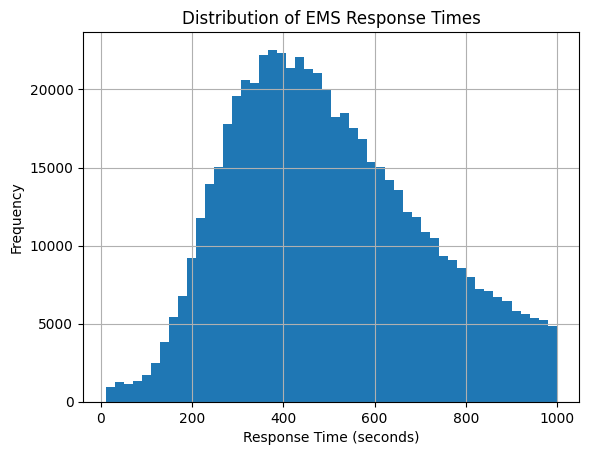

In [37]:
import matplotlib.pyplot as plt

df["INCIDENT_RESPONSE_SECONDS_QY"].hist(bins=50)
plt.xlabel("Response Time (seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of EMS Response Times")
plt.show()

In [38]:
df["INCIDENT_RESPONSE_SECONDS_QY"].describe()

count    589903.000000
mean        500.842445
std         209.560633
min          11.000000
25%         341.000000
50%         475.000000
75%         644.000000
max         999.000000
Name: INCIDENT_RESPONSE_SECONDS_QY, dtype: float64

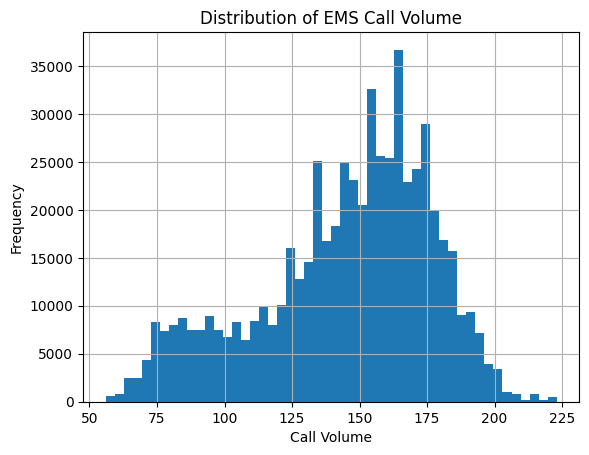

In [39]:
df["call_volume"].hist(bins=50)
plt.xlabel("Call Volume")
plt.ylabel("Frequency")
plt.title("Distribution of EMS Call Volume")
plt.show()

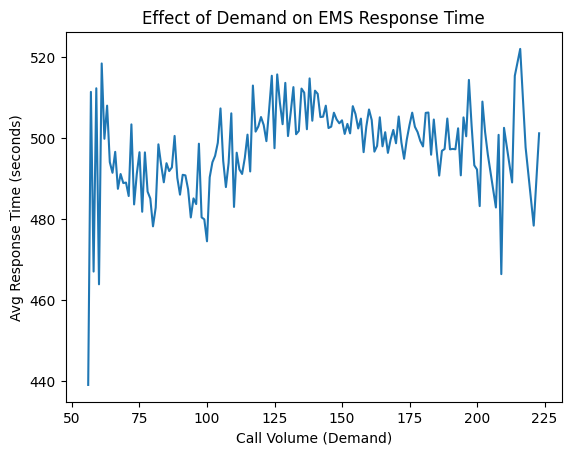

In [40]:
df.groupby("call_volume")["INCIDENT_RESPONSE_SECONDS_QY"].mean().plot()

plt.xlabel("Call Volume (Demand)")
plt.ylabel("Avg Response Time (seconds)")
plt.title("Effect of Demand on EMS Response Time")
plt.show()

C:\Users\StephenG\AppData\Local\Temp\ipykernel_2840\467627889.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("call_volume_bin")["INCIDENT_RESPONSE_SECONDS_QY"].mean().plot()


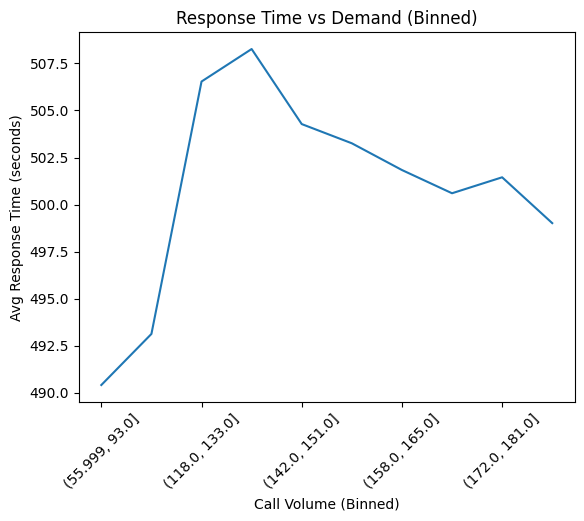

In [41]:
df["call_volume_bin"] = pd.qcut(df["call_volume"], q=10)

df.groupby("call_volume_bin")["INCIDENT_RESPONSE_SECONDS_QY"].mean().plot()

plt.xticks(rotation=45)
plt.xlabel("Call Volume (Binned)")
plt.ylabel("Avg Response Time (seconds)")
plt.title("Response Time vs Demand (Binned)")
plt.show()

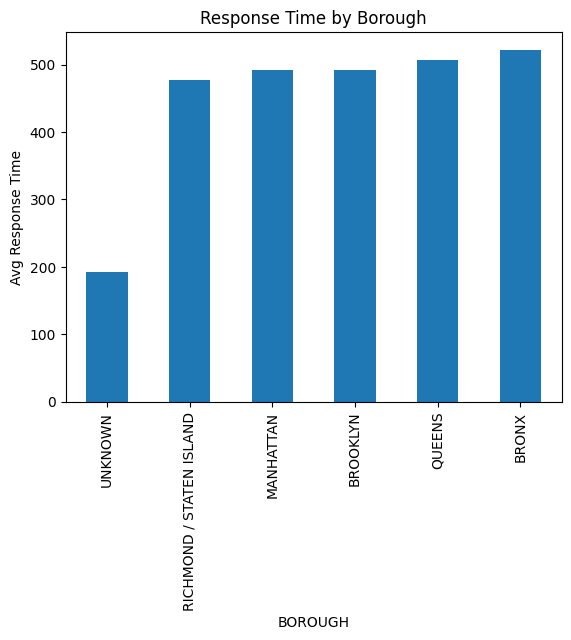

In [42]:
df.groupby("BOROUGH")["INCIDENT_RESPONSE_SECONDS_QY"].mean().sort_values().plot(kind="bar")

plt.ylabel("Avg Response Time")
plt.title("Response Time by Borough")
plt.show()

In [43]:
df["INCIDENT_RESPONSE_SECONDS_QY"].value_counts().head(10)

INCIDENT_RESPONSE_SECONDS_QY
398.0    1210
352.0    1199
370.0    1191
389.0    1186
423.0    1176
356.0    1175
400.0    1174
407.0    1170
414.0    1162
368.0    1156
Name: count, dtype: int64

In [44]:
df["INCIDENT_RESPONSE_SECONDS_QY"].describe()

count    589903.000000
mean        500.842445
std         209.560633
min          11.000000
25%         341.000000
50%         475.000000
75%         644.000000
max         999.000000
Name: INCIDENT_RESPONSE_SECONDS_QY, dtype: float64

## 2. Variable construction

In [47]:
# define high priority
df["high_priority"] = df["INITIAL_SEVERITY_LEVEL_CODE"].isin([1, 2, 3])

# define low priority
df["low_priority"] = df["INITIAL_SEVERITY_LEVEL_CODE"].isin([4, 5, 6, 7, 8])

# low-acuity demand
low_demand = (
    df[df["low_priority"]]
    .groupby(["date", "hour"])
    .size()
    .reset_index(name="low_call_volume")
)

df = df.merge(low_demand, on=["date", "hour"], how="left")

# high-acuity demand
high_demand = (
    df[df["high_priority"]]
    .groupby(["date", "hour"])
    .size()
    .reset_index(name="high_call_volume")
)

df = df.merge(high_demand, on=["date", "hour"], how="left")

df["low_call_volume"] = df["low_call_volume"].fillna(0)
df["high_call_volume"] = df["high_call_volume"].fillna(0)
#meaning low or high priority call volume

## 3. Modeling

In [49]:
# filter to high priority dataset
df_high = df[df["high_priority"]].copy()

# create log resposne time
import numpy as np
df_high["log_response_time"] = np.log(df_high["INCIDENT_RESPONSE_SECONDS_QY"])

# define x
import statsmodels.api as sm
X = df_high[["low_call_volume", "high_call_volume", "hour"]]
X = sm.add_constant(X)

#### Model 1 (Baseline)
How total demand affects response time

x: low call volume, high call volume, hour <br>
y: incident response seconds

In [51]:
y1 = df_high["INCIDENT_RESPONSE_SECONDS_QY"]
#or use log response instead
#y1 = df_high["log_response_time"]

model1 = sm.OLS(y1, X).fit()
print(model1.summary())

                                 OLS Regression Results                                 
Dep. Variable:     INCIDENT_RESPONSE_SECONDS_QY   R-squared:                       0.015
Model:                                      OLS   Adj. R-squared:                  0.015
Method:                           Least Squares   F-statistic:                     1413.
Date:                          Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                                  12:49:11   Log-Likelihood:            -1.8774e+06
No. Observations:                        282763   AIC:                         3.755e+06
Df Residuals:                            282759   BIC:                         3.755e+06
Df Model:                                     3                                         
Covariance Type:                      nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

- Each low-accuity call -> response time decreases by .19s
- Each high-acuity call -> response time increases by .6s
- Model explains .1% of variation in response time

#### Model 2 (borough added)
Demand effects controlling for geography

x: low call volume, high call volume, hour, borough <br>
y: incident response seconds

In [53]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

df_high = df[df["high_priority"]].copy()

df_high["low_call_volume"] = df_high["low_call_volume"].fillna(0)
df_high["high_call_volume"] = df_high["high_call_volume"].fillna(0)
df_high["BOROUGH"] = df_high["BOROUGH"].fillna("UNKNOWN")

df_high["log_response_time"] = np.log(df_high["INCIDENT_RESPONSE_SECONDS_QY"])

X = pd.get_dummies(
    df_high[["low_call_volume", "high_call_volume", "hour", "BOROUGH"]],
    drop_first=True
)

X = X.astype(float)
X = sm.add_constant(X)

y1 = df_high["INCIDENT_RESPONSE_SECONDS_QY"].astype(float)

model1_geo = sm.OLS(y1, X).fit()
print(model1_geo.summary())

                                 OLS Regression Results                                 
Dep. Variable:     INCIDENT_RESPONSE_SECONDS_QY   R-squared:                       0.029
Model:                                      OLS   Adj. R-squared:                  0.024
Method:                           Least Squares   F-statistic:                     6.280
Date:                          Thu, 26 Mar 2026   Prob (F-statistic):           2.80e-07
Time:                                  21:45:03   Log-Likelihood:                -9904.3
No. Observations:                          1489   AIC:                         1.982e+04
Df Residuals:                              1481   BIC:                         1.987e+04
Df Model:                                     7                                         
Covariance Type:                      nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------

- Each additional low-acutiy call -> decrease response times by -0.19 seconds
- Each additional high-acuity call -> increase response times by 0.59 seconds
- Fastest response time: Manhattan
- Lowest response time: Queens

#### Model 3 (Interaction model)
Whether low calls slow response when system is busy

x: low call volume, high call volume, interaction = low * high, hour, borough <br>
y: incident response seconds

In [43]:
df_high["interaction"] = (
    df_high["low_call_volume"] * df_high["high_call_volume"]
)

X = pd.get_dummies(
    df_high[["low_call_volume", "high_call_volume", "interaction", "hour", "BOROUGH"]],
    drop_first=True
)

X = X.astype(float)
X = sm.add_constant(X)

y1 = df_high["INCIDENT_RESPONSE_SECONDS_QY"].astype(float)

model_interaction = sm.OLS(y1, X).fit()
print(model_interaction.summary())

                                 OLS Regression Results                                 
Dep. Variable:     INCIDENT_RESPONSE_SECONDS_QY   R-squared:                       0.029
Model:                                      OLS   Adj. R-squared:                  0.024
Method:                           Least Squares   F-statistic:                     5.611
Date:                          Thu, 26 Mar 2026   Prob (F-statistic):           4.96e-07
Time:                                  21:12:57   Log-Likelihood:                -9903.8
No. Observations:                          1489   AIC:                         1.983e+04
Df Residuals:                              1480   BIC:                         1.987e+04
Df Model:                                     8                                         
Covariance Type:                      nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------

- Low-acuity demand only increases response times when high-acuity demand is also high?
- E.g. if high_call_volume = 20, effect = -0.4655 + (0.0092 *20) = -0.2815 <br>
but if high_call_volume = 100, effect = -0.4655 + (0.0092 * 100) = +0.4545 -> each additional low-acuity call increases response by 0.45s

#### Individual Severity call volume impacts

In [53]:
# loop to create call volume features for each severity per hour
    
for i in range(1, 9): 
    demand = (
        # Filter df where the severity code matches the current loop index 'i'
        df[df["INITIAL_SEVERITY_LEVEL_CODE"] == i]
        .groupby(["date", "hour"])
        .size()
        .reset_index(name=f"volume_sev_{i}")
    )

    # Merge back to the main dataframe
    df = df.merge(demand, on=["date", "hour"], how="left")
    
    # Fill NaN values with 0 for hours that had no calls of that severity
    df[f"volume_sev_{i}"] = df[f"volume_sev_{i}"].fillna(0)

display(df)

,CAD_INCIDENT_ID,INCIDENT_DATETIME,INITIAL_CALL_TYPE,INITIAL_SEVERITY_LEVEL_CODE,FINAL_CALL_TYPE,FINAL_SEVERITY_LEVEL_CODE,FIRST_ASSIGNMENT_DATETIME,VALID_DISPATCH_RSPNS_TIME_INDC,DISPATCH_RESPONSE_SECONDS_QY,FIRST_ACTIVATION_DATETIME,...,low_call_volume,high_call_volume,volume_sev_1,volume_sev_2,volume_sev_3,volume_sev_4,volume_sev_5,volume_sev_6,volume_sev_7,volume_sev_8
0,250010003,2025-01-01 00:01:53,UNC,2,UNC,2,2025-01-01 00:02:06,Y,13.0,2025-01-01 00:02:43,...,67,53,2.0,34,17,13,39,12.0,3.0,0.0
1,250010007,2025-01-01 00:03:42,ABDPN,5,ABDPN,5,2025-01-01 00:03:59,Y,17.0,2025-01-01 00:04:12,...,67,53,2.0,34,17,13,39,12.0,3.0,0.0
2,250010008,2025-01-01 00:04:36,STATEP,2,STATEP,2,2025-01-01 00:05:06,Y,30.0,2025-01-01 00:05:18,...,67,53,2.0,34,17,13,39,12.0,3.0,0.0
3,250010009,2025-01-01 00:05:26,DIFFBR,2,DIFFBR,2,2025-01-01 00:05:35,Y,9.0,2025-01-01 00:05:45,...,67,53,2.0,34,17,13,39,12.0,3.0,0.0
4,250010010,2025-01-01 00:05:48,CVAC,2,CVAC,2,2025-01-01 00:08:05,Y,137.0,2025-01-01 00:08:19,...,67,53,2.0,34,17,13,39,12.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589898,251816089,2025-06-30 23:57:13,EDP,7,UNKNOW,4,2025-06-30 23:58:07,Y,54.0,2025-06-30 23:58:39,...,74,65,0.0,38,27,14,31,15.0,14.0,0.0
589899,251816091,2025-06-30 23:58:46,INJMIN,7,INJMIN,7,2025-06-30 23:59:19,Y,33.0,2025-06-30 23:59:29,...,74,65,0.0,38,27,14,31,15.0,14.0,0.0
589900,251816092,2025-06-30 23:58:56,UNC,2,UNC,2,2025-06-30 23:59:03,Y,7.0,2025-06-30 23:59:13,...,74,65,0.0,38,27,14,31,15.0,14.0,0.0
589901,251816093,2025-06-30 23:59:13,DRUG,5,DRUG,5,2025-06-30 23:59:20,Y,7.0,2025-06-30 23:59:31,...,74,65,0.0,38,27,14,31,15.0,14.0,0.0


#### Model 4

In [55]:
import statsmodels.api as sm
import numpy as np
# 1. Filter for Severity 1 only
df_sev1 = df[df["INITIAL_SEVERITY_LEVEL_CODE"] == 1].copy()

#reponse varaible
y_sev1 = df_sev1["INCIDENT_RESPONSE_SECONDS_QY"]

# 3. Define Predictors (Volume of severities 2 through 7)
X_sev1 = df_sev1[[f"volume_sev_{i}" for i in range(2, 8)]]

# 4. Add the constant (intercept)
X_sev1 = sm.add_constant(X_sev1)

# 5. Fit the model
model_competition = sm.OLS(y_sev1, X_sev1).fit()

# 6. Display results
print(model_competition.summary())

                                 OLS Regression Results                                 
Dep. Variable:     INCIDENT_RESPONSE_SECONDS_QY   R-squared:                       0.022
Model:                                      OLS   Adj. R-squared:                  0.022
Method:                           Least Squares   F-statistic:                     37.42
Date:                          Sat, 28 Mar 2026   Prob (F-statistic):           3.29e-52
Time:                                  12:54:07   Log-Likelihood:                -74195.
No. Observations:                         11568   AIC:                         1.484e+05
Df Residuals:                             11560   BIC:                         1.485e+05
Df Model:                                     7                                         
Covariance Type:                      nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

## 4. Simulation